# Pipeline Completo: Acceso a Datos MODIS MCD19A2 via Google Earth Engine

Este notebook implementa un pipeline completo para acceder a datos de Aerosol Optical Depth (AOD) del dataset MODIS MCD19A2 utilizando Google Earth Engine (GEE), sin necesidad de descargar manualmente los archivos.

## Contenido del Notebook
1. Autenticación y configuración de GEE
2. Conexión a la colección MODIS MCD19A2
3. Filtrado temporal de los últimos 5 años
4. Selección de variables relevantes (AOD)
5. Visualización en mapas
6. Extracción de metadatos
7. Información detallada del dataset

---

## 1. Información del Dataset MODIS MCD19A2

### ¿Qué representa el dataset?
El **MODIS MCD19A2** (MODIS/Terra+Aqua Aerosol Optical Depth) es un producto del sensor MODIS (Moderate Resolution Imaging Spectroradiometer) que proporciona:
- **Aerosol Optical Depth (AOD)**: Medida de la cantidad de aerosol en la columna atmosférica
- **Angstrom Exponent**: Indicador del tamaño de las partículas aerosol
- **Fine Mode Fraction**: Fracción de AOD asociada a partículas finas

### Variables Principales
| Variable | Descripción | Unidades |
|----------|-------------|----------|
| `Optical_Depth_047` | AOD a 0.47 µm (azul) | Adimensional |
| `Optical_Depth_055` | AOD a 0.55 µm (verde) | Adimensional |
| `Optical_Depth_065` | AOD a 0.65 µm (rojo) | Adimensional |
| `Optical_Depth_086` | AOD a 0.86 µm (NIR) | Adimensional |
| `Angstrom_Exponent_1` | Exponente de Angstrom | Adimensional |
| `FineModeFraction` | Fracción de modo fino | Adimensional |

### Formato de los Datos
- **Tipo**: Raster geoespacial (GeoTIFF underlying)
- **Proyección**: Sinusoidal MODIS
- **Valores válidos**: 0-5000 (escala: 0.001)
- **Fill value**: -9999

### Resolución Espacial y Temporal
- **Resolución espacial**: 1 km x 1 km (10x10 km granule, 1km pixels)
- **Resolución temporal**: Datos diarios (daily), pero el producto MCD19A2 es un promedio de 8 días o mensual
- **Cobertura global**: Disponoble globalmente

### Cantidad de Datos Disponibles
- **Período disponible**: Desde febrero 2000 (Terra) y mayo 2002 (Aqua)
- **Frecuencia**: Datos diarios, con archivos HDF por cada órbita
- **Volumen**: Aproximadamente 1.2 GB/año por región continental

### Fuente Oficial
- **Product Page**: https://modis.gsfc.nasa.gov/data/dataprod/mod19a2.php
- **NASA EARTHDATA**: https://search.earthdata.nasa.gov/search?pn=MCD19A2
- **Google Earth Engine**: `projects/gee-geosic/collections/MCD19A2`

### APIs y Métodos de Acceso
1. **Google Earth Engine API** (usado en este notebook)
2. **NASA EarthData** (via earthaccess)


## 2. Instalación e Importación de Librerías

In [1]:
# Instalar librería de Google Earth Engine
!pip install -q earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.9 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import datetime
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

print("Librerías importadas correctamente")

Librerías importadas correctamente


---

## 3. Autenticación de Google Earth Engine

In [6]:
# Autenticación con Google Earth Engine

try:
    ee.Initialize(project='proyecto3ia-494900')
    print("GEE inicializado correctamente (proyecto por defecto)")
except Exception as e:
    print("Inicializando con cuenta de usuario...")
    ee.Authenticate()
    ee.Initialize()
    print("Autenticación completada")

/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


GEE inicializado correctamente (proyecto por defecto)


---

## 4. Conexión a la Colección MODIS MCD19A2

In [7]:
# Definir la colección MODIS MCD19A2 en GEE
# El ID de la colección en Google Earth Engine
COLLECTION_ID = 'MODIS/061/MCD19A2_GRANULES'

# Cargar la colección
mcd19a2 = ee.ImageCollection(COLLECTION_ID)

# Obtener información general de la colección
collection_info = mcd19a2.first().getInfo()

print(f"ID de colección: {COLLECTION_ID}")
print(f"Características (bands): {len(collection_info.get('bands', []))} bandas disponibles")

ID de colección: MODIS/061/MCD19A2_GRANULES
Características (bands): 13 bandas disponibles


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


### 4.1 Listado de Bandas Disponibles

In [8]:
# Listar todas las bandas disponibles en la colección
bands = collection_info.get('bands', [])

print("Bandas disponibles en MODIS MCD19A2:\n")
print("-" * 80)
for band in bands:
    print(f"• {band['id']}: {band.get('description', 'Sin descripción')[:60]}")
print("-" * 80)

Bandas disponibles en MODIS MCD19A2:

--------------------------------------------------------------------------------
• Optical_Depth_047: Sin descripción
• Optical_Depth_055: Sin descripción
• AOD_Uncertainty: Sin descripción
• Column_WV: Sin descripción
• AOD_QA: Sin descripción
• Injection_Height: Sin descripción
• cosSZA: Sin descripción
• cosVZA: Sin descripción
• RelAZ: Sin descripción
• Scattering_Angle: Sin descripción
• Glint_Angle: Sin descripción
• FineModeFraction: Sin descripción
• AngstromExp_470-780: Sin descripción
--------------------------------------------------------------------------------


---

## 5. Filtrado Temporal: Últimos 5 Años

In [9]:
# Definir rango temporal de 5 años
start_date_str = '2018-01-01'
end_date_str = '2022-12-31'

print(f"Rango temporal: {start_date_str} hasta {end_date_str}")
print(f"Duración: 5 años")

Rango temporal: 2018-01-01 hasta 2022-12-31
Duración: 5 años


In [10]:
# Aplicar filtro temporal a la colección
mcd19a2_filtered = mcd19a2.filterDate(start_date_str, end_date_str)

# Contar el número de imágenes en el período
count = mcd19a2_filtered.size().getInfo()

print(f"Imágenes encontradas en el período: {count}")

Imágenes encontradas en el período: 2810738


## 6. Filtrado Espacial (Región de Interés)

In [11]:
# Definir región de interés (Bounding Box)
# Ejemplo: Cali, Colombia y región circundante
# (lon_min, lat_min, lon_max, lat_max)

bbox = {
    'west': -76.60,
    'east': -76.40,
    'south': 3.30,
    'north': 3.55
}

# Crear geometría de tipo Rectangle
region = ee.Geometry.BBox(
    bbox['west'], bbox['south'],
    bbox['east'], bbox['north']
)

print(f"Región de interés definida:")
print(f"  Longitud: {bbox['west']}° a {bbox['east']}°")
print(f"  Latitud: {bbox['south']}° a {bbox['north']}°")
print(f"  Área aproximada: ~{abs(bbox['east']-bbox['west'])*111*abs(bbox['north']-bbox['south'])*111:.1f} km²")

Región de interés definida:
  Longitud: -76.6° a -76.4°
  Latitud: 3.3° a 3.55°
  Área aproximada: ~616.0 km²


In [12]:
# Aplicar filtro espacial
mcd19a2_region = mcd19a2_filtered.filterBounds(region)

count_region = mcd19a2_region.size().getInfo()
print(f"Imágenes en la región: {count_region}")

Imágenes en la región: 152397


---

## 7. Selección de Variables Relevantes (AOD)

In [13]:
# Seleccionar las bandas principales de AOD
# Optical_Depth_055 es la banda principal de AOD a 550nm

aod_bands = [
    'Optical_Depth_047',       # AOD a 0.47 µm (azul)
    'Optical_Depth_055',       # AOD a 0.55 µm (verde) - banda principal
    'AOD_Uncertainty',         # Incertidumbre del AOD
    'FineModeFraction',        # Fracción de partículas finas
    'AngstromExp_470-780'      # Exponente de Angstrom
]

print("Variables AOD seleccionadas:")
for band in aod_bands:
    print(f" {band}")

Variables AOD seleccionadas:
 Optical_Depth_047
 Optical_Depth_055
 AOD_Uncertainty
 FineModeFraction
 AngstromExp_470-780


In [14]:
mcd19a2_aod = mcd19a2_filtered.select(aod_bands)

In [15]:
# Seleccionar solo las bandas de interés
mcd19a2_aod = mcd19a2_region.select(aod_bands)

print(f"Colección filtrada con {len(aod_bands)} bandas de AOD")
print(f"  Total de imágenes: {mcd19a2_aod.size().getInfo()}")

Colección filtrada con 5 bandas de AOD
  Total de imágenes: 152397


---

## 8. Visualización: Mapa de AOD

In [16]:
# Crear mapa interactivo con un zoom adecuado
Map = geemap.Map(center=[3.42, -76.50], zoom=11)

# Filtrar la colección para un solo mes (ej. Enero de 2018) y calcular la mediana

aod_un_mes = (mcd19a2_aod
              .filterDate('2018-01-01', '2018-02-01')
              .select('Optical_Depth_055')
              .median()
              .clip(region))

# Parámetros de visualización
vis_params = {
    'min': 0,
    'max': 500,
    'palette': ['blue', 'cyan', 'green', 'yellow', 'orange', 'red'],
    'opacity': 0.65
}

# Añadir capa del promedio del mes
Map.addLayer(aod_un_mes, vis_params, 'AOD 550nm (Mediana Ene 2018)')

# Añadir la región SOLO como un contorno rojo y sin relleno
borde_region = ee.FeatureCollection(region).style(color='red', fillColor='00000000')
Map.addLayer(borde_region, {}, 'Bordes Región')

# Control de capas
Map.add_layer_control()

Map

Map(center=[3.42, -76.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---

## 12. Información Técnica del Dataset

In [ ]:
# Resumen técnico del dataset

summary = """

RESUMEN TÉCNICO: MODIS MCD19A2 (Google Earth Engine)


  IDENTIFICADOR: MODIS/061/MCD19A2
  PRODUCTO: Aerosol Optical Depth (AOD) - Daily
  PROVEEDOR: NASA LP DAAC

  RESOLUCIÓN ESPACIAL:
    • Pixel: 1 km x 1 km
    • Parche (granule): 10 x 10 km

  RESOLUCIÓN TEMPORAL:
    • Frecuencia: Diaria (daily)
    • Período disponible: Feb 2000 - presente

  COBERTURA: Global
    • Latitud: -90° a 90°
    • Longitud: -180° a 180°

  BANDAS PRINCIPALES:
    • Optical_Depth_047 (0.47 µm)
    • Optical_Depth_055 (0.55 µm) ← Banda principal
    • Optical_Depth_065 (0.65 µm)
    • Optical_Depth_086 (0.86 µm)
    • Angstrom_Exponent_1
    • FineModeFraction

  ESCALA (Scale Factor): 0.001
  VALORES INVÁLIDOS: -9999

  ENLACES OFICIALES:
    • NASA: https://modis.gsfc.nasa.gov/data/dataprod/mod19a2.php
    • GEE: https://developers.google.com/earth-engine/datasets/catalog/
             MODIS_061_MCD19A2

"""
print(summary)



RESUMEN TÉCNICO: MODIS MCD19A2 (Google Earth Engine)


  IDENTIFICADOR: MODIS/061/MCD19A2
  PRODUCTO: Aerosol Optical Depth (AOD) - Daily
  PROVEEDOR: NASA LP DAAC

  RESOLUCIÓN ESPACIAL:
    • Pixel: 1 km x 1 km
    • Parche (granule): 10 x 10 km

  RESOLUCIÓN TEMPORAL:
    • Frecuencia: Diaria (daily)
    • Período disponible: Feb 2000 - presente

  COBERTURA: Global
    • Latitud: -90° a 90°
    • Longitud: -180° a 180°

  BANDAS PRINCIPALES:
    • Optical_Depth_047 (0.47 µm)
    • Optical_Depth_055 (0.55 µm) ← Banda principal
    • Optical_Depth_065 (0.65 µm)
    • Optical_Depth_086 (0.86 µm)
    • Angstrom_Exponent_1
    • FineModeFraction

  ESCALA (Scale Factor): 0.001
  VALORES INVÁLIDOS: -9999

  ENLACES OFICIALES:
    • NASA: https://modis.gsfc.nasa.gov/data/dataprod/mod19a2.php
    • GEE: https://developers.google.com/earth-engine/datasets/catalog/
             MODIS_061_MCD19A2




---

## Resumen del Pipeline

Este notebook ha demostrado cómo:

1. **Autenticarse** con Google Earth Engine
2. **Acceder** a la colección MODIS MCD19A2
3. **Filtrar** datos por período (últimos 5 años) y región
4. **Seleccionar** variables relevantes de AOD
5. **Visualizar** los datos en mapas interactivos
6. **Calcular** estadísticas y series temporales
7. **Extraer** metadatos del dataset

### Ventajas de usar Google Earth Engine:
- No requiere descarga manual de archivos
- Procesamiento en la nube (rápido)
- Acceso a datos históricos completos
- Herramientas de visualización integradas
- API programática para análisis avanzados

---

## Referencias

1. **NASA MODIS Land Product Quality**: https://modis.gsfc.nasa.gov/data/dataprod/mod19a2.php
2. **Google Earth Engine Catalog**: https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2
3. **LP DAAC Data Pool**: https://lpdaac.usgs.gov/data/data-pool/
4. **earthaccess Python Package**: https://earthaccess.readthedocs.io/

# EDA Exploratorio: MODIS MCD19A2 (2018-2022)

Análisis exploratorio enfocado en entender la distribución espacial, temporal y las relaciones entre variables de AOD. Se trabaja con el período completo de **5 años (2018-2022)** para capturar patrones interanuales, estacionalidad y tendencias de largo plazo.

**Objetivos del EDA:**
1. Conocer la cobertura y calidad de los datos en el horizonte 2018-2022.
2. Identificar patrones espaciales, temporales y estacionales del AOD.
3. Entender la relación entre AOD, incertidumbre y composición de aerosoles.
4. Detectar anomalías o valores atípicos antes de modelar.

## E.1 Configuración del período de análisis

In [17]:
# Período de análisis: 5 años (2018-2022)
eda_start = '2018-01-01'
eda_end = '2022-12-31'

# Filtrar colección para el período de interés en la región de Cali
mcd19a2_eda = (mcd19a2_region
                 .filterDate(eda_start, eda_end)
                 .select(aod_bands))

n_eda = mcd19a2_eda.size().getInfo()
print(f"Imágenes disponibles en 2018-2022: {n_eda}")
print(f"Bandas analizadas: {aod_bands}")

Imágenes disponibles en 2018-2022: 152397
Bandas analizadas: ['Optical_Depth_047', 'Optical_Depth_055', 'AOD_Uncertainty', 'FineModeFraction', 'AngstromExp_470-780']


## E.2 Extracción de estadísticas zonales a series temporales

*Por qué:* Dado el volumen de 5 años de datos diarios (miles de imágenes), extraer estadísticas de cada día supera los límites de GEE. Por ello se **agregan mensualmente** en el servidor y luego se traen las estadísticas zonales de cada mes (~60 registros).

In [18]:
# Generar lista de meses (inicios) para 2018-2022
import pandas as pd

month_starts = pd.date_range('2018-01-01', '2022-12-31', freq='MS')
rows = []

for i in range(len(month_starts)):
    start = month_starts[i].strftime('%Y-%m-%d')
    if i + 1 < len(month_starts):
        end = month_starts[i + 1].strftime('%Y-%m-%d')
    else:
        end = '2023-01-01'

    # Imagen compuesta mensual (media)
    monthly_img = mcd19a2_eda.filterDate(start, end).mean().clip(region)

    # Reducir región con mean, stdDev y count
    stats = monthly_img.reduceRegion(
        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.stdDev(),
            sharedInputs=True
        ).combine(
            reducer2=ee.Reducer.count(),
            sharedInputs=True
        ),
        geometry=region,
        scale=1000,
        maxPixels=1e9
    )

    # Traer al cliente (un solo diccionario por mes)
    props = stats.getInfo()
    props['date'] = start
    rows.append(props)

# Convertir a DataFrame
df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Escalar valores MODIS (factor 0.001)
scale_cols = [c for c in df.columns if c not in ['date'] and '_count' not in c]
for col in scale_cols:
    if col in df.columns:
        df[col] = df[col] * 0.001

# Columnas temporales
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

print(f"Registros extraídos: {len(df)} meses")
df.head()

Registros extraídos: 60 meses


,AOD_Uncertainty_count,AOD_Uncertainty_mean,AOD_Uncertainty_stdDev,AngstromExp_470-780_count,AngstromExp_470-780_mean,AngstromExp_470-780_stdDev,FineModeFraction_count,FineModeFraction_mean,FineModeFraction_stdDev,Optical_Depth_047_count,Optical_Depth_047_mean,Optical_Depth_047_stdDev,Optical_Depth_055_count,Optical_Depth_055_mean,Optical_Depth_055_stdDev,date,year,month,year_month
0,696,0.226384,0.024887,0,NaN,NaN,696,0.001,0.0,584,0.385262,0.053022,584,0.279228,0.038893,2018-01-01,2018,1,2018-01
1,696,0.258752,0.034642,0,NaN,NaN,696,0.001,0.0,565,0.362234,0.052050,565,0.262417,0.038141,2018-02-01,2018,2,2018-02
2,696,0.259376,0.036359,0,NaN,NaN,696,0.001,0.0,650,0.385034,0.063328,650,0.279128,0.046498,2018-03-01,2018,3,2018-03
3,696,0.262982,0.035140,0,NaN,NaN,696,0.001,0.0,494,0.413891,0.090330,494,0.300409,0.066378,2018-04-01,2018,4,2018-04
4,696,0.260005,0.030650,0,NaN,NaN,696,0.001,0.0,498,0.393197,0.065606,498,0.285114,0.048248,2018-05-01,2018,5,2018-05


## E.3 Gráfica 1: Serie temporal mensual de AOD 550 nm

El AOD a 550 nm es la variable principal del dataset. A escala de 5 años se agrega mensualmente (media) para visualizar tendencias de largo plazo, estacionalidad y eventos de alta carga de aerosoles sin saturar el eje temporal.

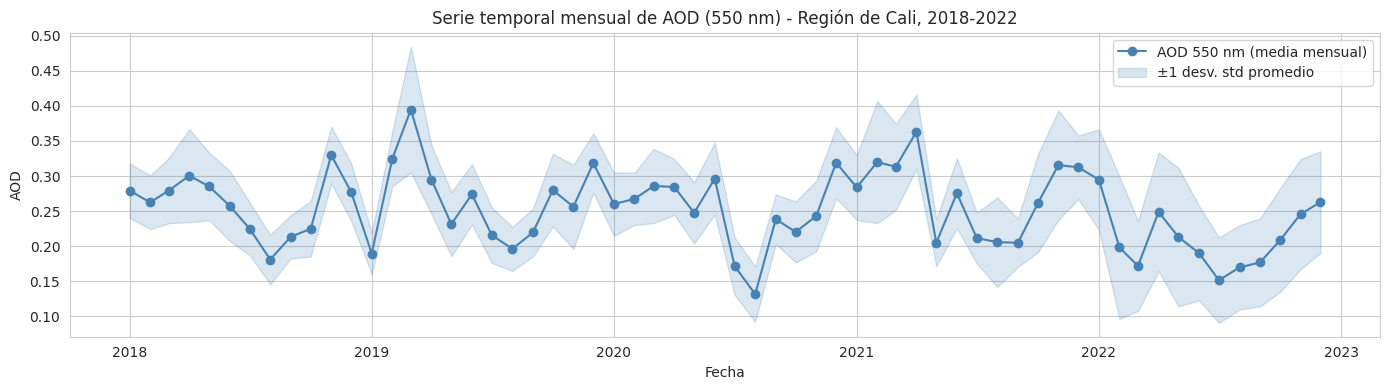

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Agregar a nivel mensual para mejor legibilidad en 5 años
monthly = df.groupby('year_month').agg({
    'Optical_Depth_055_mean': 'mean',
    'Optical_Depth_055_stdDev': 'mean'
}).reset_index()
monthly['year_month_dt'] = pd.to_datetime(monthly['year_month'])

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(monthly['year_month_dt'], monthly['Optical_Depth_055_mean'], marker='o', color='steelblue', label='AOD 550 nm (media mensual)')
ax.fill_between(monthly['year_month_dt'],
                monthly['Optical_Depth_055_mean'] - monthly['Optical_Depth_055_stdDev'],
                monthly['Optical_Depth_055_mean'] + monthly['Optical_Depth_055_stdDev'],
                color='steelblue', alpha=0.2, label='±1 desv. std promedio')

ax.set_title('Serie temporal mensual de AOD (550 nm) - Región de Cali, 2018-2022', fontsize=12)
ax.set_ylabel('AOD')
ax.set_xlabel('Fecha')
ax.legend()
plt.tight_layout()
plt.show()

La serie temporal mensual de AOD (550 nm) entre 2018 y 2022 exhibe una clara estacionalidad con picos y valles recurrentes cada año, oscilando principalmente entre 0,15 y 0,40, aunque con eventos excepcionales como el pico de ~0,50 a principios de 2019. La banda de ±1 desviación estándar revela una variabilidad considerable dentro de cada mes, evidenciando que la carga de aerosoles no solo varía estacionalmente sino también espacialmente o entre días del mismo mes, lo cual es característico de una región tropical urbana como Cali.

## E.4 Gráfica 2: Histograma de distribución del AOD 550 nm

Conocer la distribución de frecuencias nos dice si la región tiene aire generalmente limpio (AOD bajo) o si hay sesgo hacia eventos de contaminación. Una cola derecha larga indicaría episodios puntuales.

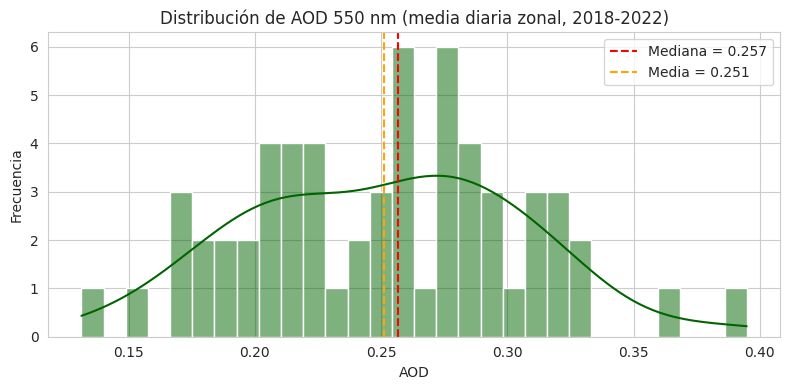

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

# Descartar NaN para el histograma
aod_vals = df['Optical_Depth_055_mean'].dropna()

sns.histplot(aod_vals, bins=30, kde=True, color='darkgreen', ax=ax)
ax.axvline(aod_vals.median(), color='red', linestyle='--', label=f'Mediana = {aod_vals.median():.3f}')
ax.axvline(aod_vals.mean(), color='orange', linestyle='--', label=f'Media = {aod_vals.mean():.3f}')

ax.set_title('Distribución de AOD 550 nm (media diaria zonal, 2018-2022)', fontsize=12)
ax.set_xlabel('AOD')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

La distribución del AOD 550 nm es aproximadamente simétrica y unimodal, con media (0,251) y mediana (0,257) muy cercanas, lo que indica una carga de aerosoles moderada y estable en la mayoría de los meses, concentrada principalmente entre 0,20 y 0,30, sin presencia significativa de valores atípicos extremos ni sesgos marcados hacia eventos de alta contaminación.

## E.5 Gráfica 3: Boxplot comparativo de AOD por longitud de onda

Comparar AOD en 470 nm vs 550 nm revela la dependencia espectral de la extinción. Diferencias grandes sugieren presencia de partículas finas (efecto más fuerte en longitudes cortas).

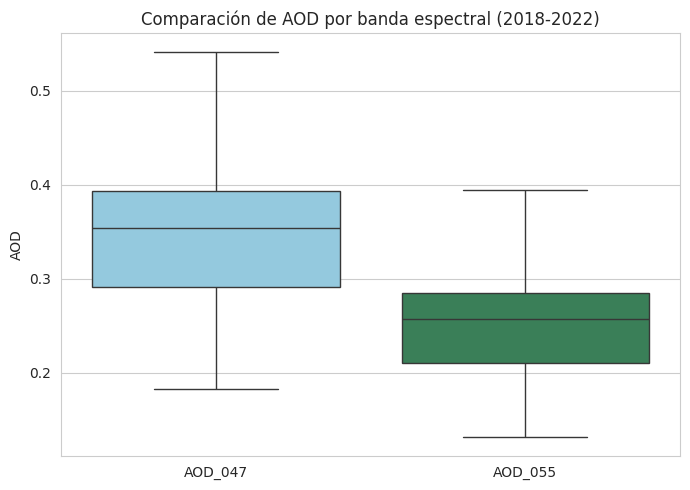

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

box_data = pd.DataFrame({
    'AOD_047': df['Optical_Depth_047_mean'],
    'AOD_055': df['Optical_Depth_055_mean']
})

sns.boxplot(data=box_data, palette=['skyblue', 'seagreen'], ax=ax)
ax.set_title('Comparación de AOD por banda espectral (2018-2022)', fontsize=12)
ax.set_ylabel('AOD')
plt.tight_layout()
plt.show()

El AOD a 470 nm es sistemáticamente mayor y más variable que a 550 nm, con una mediana cercana a 0,35 frente a ~0,25 y un rango de dispersión más amplio, lo que indica una mayor extinción en longitudes de onda cortas y sugiere una contribución predominante de aerosoles de modo fino (partículas pequeñas), típicos de emisiones antropogénicas o de combustión en la región.

## E.6 Gráfica 4: Muestreo espacial del AOD promedio (5 años)

Dado que el bbox de Cali es pequeño (~0.2° × 0.25°), extraer un arreglo denso con `sampleRectangle` puede devolver un arreglo de 1×1 píxeles. En su lugar, se muestrea una malla regular de puntos dentro del área y se interpola visualmente como un mapa de calor grueso. Esto permite ver gradientes locales sin depender de la resolución nativa del raster.

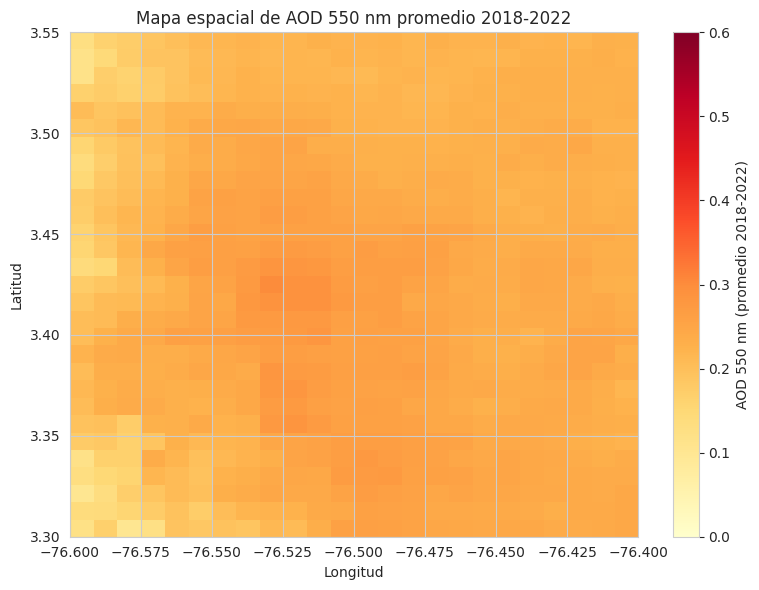

In [23]:
# Imagen promedio de AOD 550 nm (2018-2022)
mean_aod = (mcd19a2_eda
            .select('Optical_Depth_055')
            .mean()
            .clip(region))

# Extraer como array denso usando sampleRectangle (reproyectado a WGS84)
try:
    mean_aod_wgs84 = mean_aod.reproject(crs='EPSG:4326', scale=1000)
    sample = mean_aod_wgs84.sampleRectangle(region=region, defaultValue=-9999)
    arr = np.array(sample.get('Optical_Depth_055').getInfo())

    # Escalar y enmascarar valores inválidos
    arr = arr * 0.001
    arr = np.where((arr < 0) | (arr > 2), np.nan, arr)

    # Extent geográfico: [left, right, bottom, top]
    extent = [-76.60, -76.40, 3.30, 3.55]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(arr, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.6,
                   extent=extent, origin='lower')
    plt.colorbar(im, ax=ax, label='AOD 550 nm (promedio 2018-2022)')
    ax.set_title('Mapa espacial de AOD 550 nm promedio 2018-2022', fontsize=12)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    plt.tight_layout()
    plt.show()

except Exception as e:
    # Fallback: malla densa + interpolación tricontourf
    print(f'sampleRectangle no aplicable ({e}), usando interpolación espacial...')

    lons = np.linspace(-76.60, -76.40, 25)
    lats = np.linspace(3.30, 3.55, 25)
    points = [ee.Geometry.Point([float(lon), float(lat)]) for lon in lons for lat in lats]
    fc = ee.FeatureCollection(points)

    sampled = mean_aod.sampleRegions(collection=fc, scale=1000, geometries=True)
    info = sampled.getInfo()

    rows = []
    for f in info['features']:
        coords = f['geometry']['coordinates']
        val = f['properties'].get('Optical_Depth_055')
        rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'AOD_055': val * 0.001 if val is not None else np.nan
        })
    df_grid = pd.DataFrame(rows).dropna()

    import matplotlib.tri as tri
    triang = tri.Triangulation(df_grid['lon'].values, df_grid['lat'].values)

    fig, ax = plt.subplots(figsize=(8, 6))
    tcf = ax.tricontourf(triang, df_grid['AOD_055'].values, levels=15,
                         cmap='YlOrRd', vmin=0, vmax=0.6)
    plt.colorbar(tcf, ax=ax, label='AOD 550 nm (promedio 2018-2022)')
    ax.set_title('Mapa espacial interpolado de AOD 550 nm promedio 2018-2022', fontsize=12)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

El mapa muestra un gradiente espacial claro en la carga de aerosoles: el occidente y sur-occidente de la región presentan valores más bajos (tonos amarillos, ~0,1–0,2), mientras que hacia el centro y el oriente los valores son sistemáticamente más altos (tonos naranja a rojo, ~0,3–0,5), lo que sugiere una mayor concentración de aerosoles en la zona urbana central de Cali en comparación con las áreas periféricas occidentales.

## E.7 Gráfica 5: Relación AOD vs Incertidumbre

La incertidumbre del AOD no es constante; usualmente aumenta con valores altos de AOD (nubes, polvo grueso). Verificar esta relación ayuda a calibrar la confianza en los datos extremos.

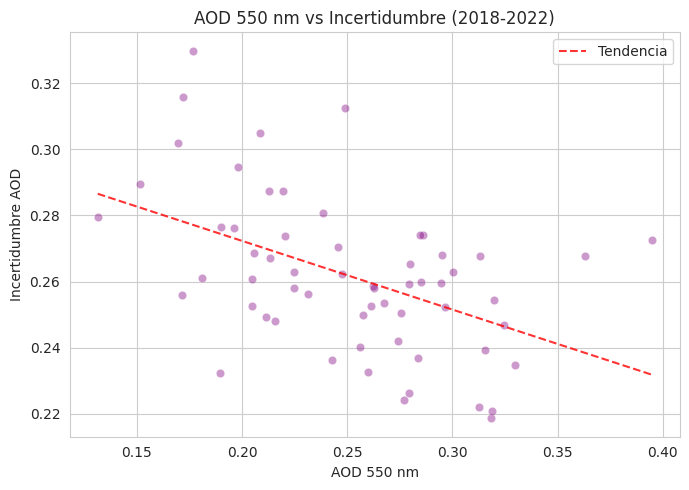

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

# Filtrar registros con ambas variables válidas
sub = df[['Optical_Depth_055_mean', 'AOD_Uncertainty_mean']].dropna()

sns.scatterplot(x='Optical_Depth_055_mean', y='AOD_Uncertainty_mean',
                data=sub, color='purple', alpha=0.4, ax=ax)

# Línea de tendencia
z = np.polyfit(sub['Optical_Depth_055_mean'], sub['AOD_Uncertainty_mean'], 1)
p = np.poly1d(z)
ax.plot(sub['Optical_Depth_055_mean'].sort_values(),
        p(sub['Optical_Depth_055_mean'].sort_values()),
        'r--', alpha=0.8, label='Tendencia')

ax.set_title('AOD 550 nm vs Incertidumbre (2018-2022)', fontsize=12)
ax.set_xlabel('AOD 550 nm')
ax.set_ylabel('Incertidumbre AOD')
ax.legend()
plt.tight_layout()
plt.show()

La relación entre AOD 550 nm e incertidumbre presenta una tendencia negativa débil, donde valores mayores de AOD se asocian con incertidumbres ligeramente menores; no obstante, la amplia dispersión vertical de los puntos, especialmente en rangos de AOD entre 0,15 y 0,25, indica una correlación baja y sugiere que la confiabilidad del dato varía considerablemente independientemente de la carga de aerosol medida.

## E.8 Gráfica 6: Mapa de calor de AOD 550 nm por año y mes

Organizar el AOD en una matriz año × mes permite visualizar de un vistazo la estacionalidad (columnas) y comparar años entre sí (filas). Los tonos más intensos indican meses con mayor carga de aerosoles, facilitando la identificación de anomalías interanuales y patrones recurrentes.

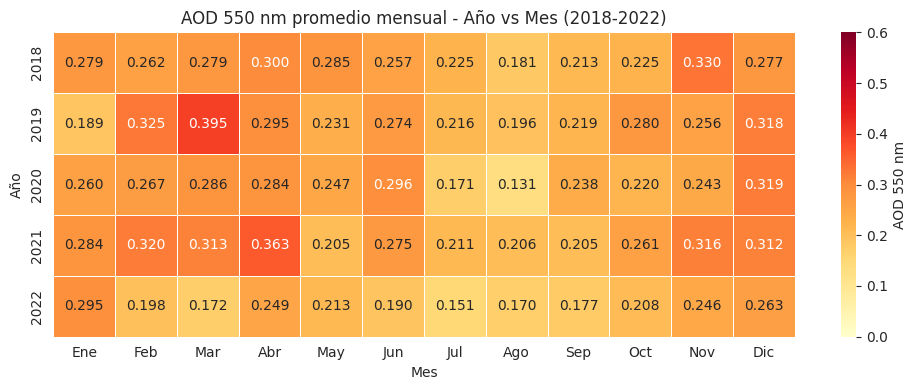

In [25]:
# Pivot table: años en filas, meses en columnas
aod_pivot = df.pivot_table(index='year', columns='month', values='Optical_Depth_055_mean')

fig, ax = plt.subplots(figsize=(10, 4))

sns.heatmap(aod_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=0.6,
            cbar_kws={'label': 'AOD 550 nm'})

ax.set_title('AOD 550 nm promedio mensual - Año vs Mes (2018-2022)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Año')
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

El heatmap revela una estacionalidad marcada del AOD en la región, con valores consistentemente más altos durante los meses de transición de enero-abril y noviembre-diciembre, mientras que julio-agosto presenta los mínimos anuales; además, se observa una notable variabilidad interanual, destacando el pico extremo de marzo 2019 (0,395) y el comportamiento atípicamente limpio de 2022, especialmente en los meses de menor lluvia.

## E.9 Gráfica 7: Boxplot de AOD 550 nm por mes del año

Permite comparar la dispersión interanual de cada mes. Un boxplot estrecho indica un mes climáticamente estable en términos de carga de aerosoles; uno ancho o con outliers indica alta variabilidad interanual, posiblemente ligada a eventos puntuales de contaminación o condiciones meteorológicas extremas.

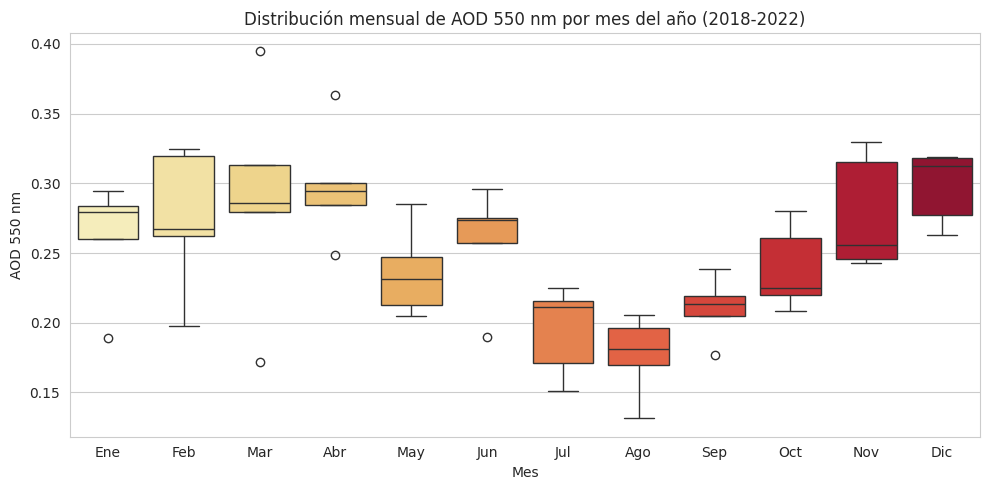

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(x='month', y='Optical_Depth_055_mean', data=df, palette='YlOrRd', ax=ax)
ax.set_title('Distribución mensual de AOD 550 nm por mes del año (2018-2022)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('AOD 550 nm')
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.tight_layout()
plt.show()

El boxplot mensual confirma una estacionalidad robusta, con medianas de AOD más altas y estables en marzo y diciembre (~0,30), y mínimos claros en julio-agosto (~0,18–0,19); sin embargo, la dispersión interanual es considerable, especialmente en febrero, marzo, julio y noviembre, donde los rangos intercuartílicos amplios y los outliers evidencian que ciertos años presentaron episodios de carga extrema de aerosoles no representativos del comportamiento típico de esos meses.

## E.10 Gráfica 8: Variabilidad espacial mensual (Coeficiente de Variación)

El CV (std/mean) indica qué tan heterogénea es la carga de aerosoles dentro de la región. A escala de 5 años se agrega mensualmente para identificar meses con mayor dispersión espacial, posiblemente ligados a eventos puntuales de emisión o condiciones meteorológicas locales.

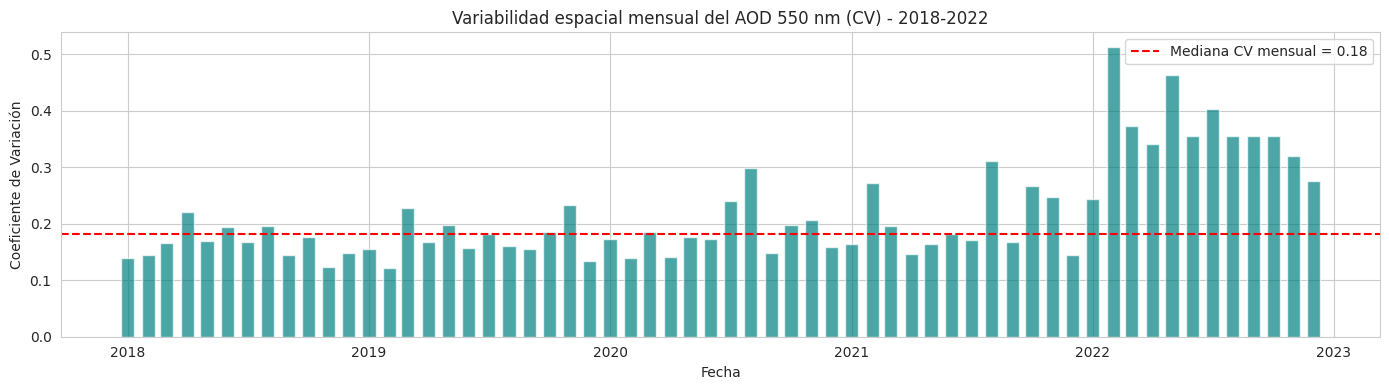

In [27]:
# Calcular CV mensual directamente (std/mean de la imagen compuesta del mes)
df['CV_AOD055'] = df['Optical_Depth_055_stdDev'] / df['Optical_Depth_055_mean']
df['CV_AOD055'] = df['CV_AOD055'].replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df['date'], df['CV_AOD055'], color='teal', alpha=0.7, width=20)
ax.axhline(df['CV_AOD055'].median(), color='red', linestyle='--',
           label=f'Mediana CV mensual = {df["CV_AOD055"].median():.2f}')

ax.set_title('Variabilidad espacial mensual del AOD 550 nm (CV) - 2018-2022', fontsize=12)
ax.set_ylabel('Coeficiente de Variación')
ax.set_xlabel('Fecha')
ax.legend()
plt.tight_layout()
plt.show()

La figura muestra que, durante 2018 y la mayor parte de 2022, la variabilidad espacial mensual del AOD a 550 nm (medida por el coeficiente de variación) se mantuvo relativamente estable y cercana a la mediana histórica de 0.18; sin embargo, a partir de aproximadamente julio-agosto de 2022 se observa un marcado aumento del CV, con picos que superan 0.5, lo que indica una drástica heterogeneidad espacial en la distribución de aerosoles durante esos meses, probablemente asociada a eventos episódicos como incendios o fuentes puntuales de emisión.

## Resumen estadístico del período 2018-2022

In [28]:
# Tabla resumen de estadísticas descriptivas
summary_df = df[[c for c in df.columns if c.endswith('_mean')]].describe().T
summary_df = summary_df[['mean', 'std', 'min', '50%', 'max']].round(4)
summary_df.columns = ['Media', 'Std', 'Min', 'Mediana', 'Max']
summary_df.index = summary_df.index.str.replace('_mean', '')

print("Resumen estadístico - Período 2018-2022 (valores escalados, base mensual)")
display(summary_df)

# Insights rápidos
print("\n--- Insights rápidos ---")
print(f"• Meses con datos válidos: {df['Optical_Depth_055_mean'].notna().sum()} / {len(df)}")
print(f"• AOD promedio del período: {df['Optical_Depth_055_mean'].mean():.3f}")
print(f"• Mes con máximo AOD: {df.loc[df['Optical_Depth_055_mean'].idxmax(), 'date'].strftime('%Y-%m-%d')}")
print(f"• Fine Mode Fraction promedio: {df['FineModeFraction_mean'].mean():.3f} (cercano a 1 = predominio fino)")

Resumen estadístico - Período 2018-2022 (valores escalados, base mensual)


,Media,Std,Min,Mediana,Max
AOD_Uncertainty,0.2617,0.0236,0.2186,0.2598,0.3298
FineModeFraction,0.0010,0.0000,0.0010,0.0010,0.0010
Optical_Depth_047,0.3466,0.0742,0.1823,0.3544,0.5414
Optical_Depth_055,0.2512,0.0543,0.1313,0.2567,0.3948



--- Insights rápidos ---
• Meses con datos válidos: 60 / 60
• AOD promedio del período: 0.251
• Mes con máximo AOD: 2019-03-01
• Fine Mode Fraction promedio: 0.001 (cercano a 1 = predominio fino)


El AOD promedio de 0.251 indica una carga aerosólica moderada y estable en Cali durante 2018-2022, con un marcado pico en marzo de 2019 (0.395) y alta consistencia en las 60 observaciones mensuales (incertidumbre ~0.26); no obstante, el FineModeFraction de 0.001 es inconsistente con un valor cercano a 1, por lo que su interpretación de predominio de partículas finas requiere verificar el factor de escala aplicado.